# Plot IMBIE basins

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy.io
import h5py
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon
import os
import tempfile
import warnings
warnings.filterwarnings('ignore')

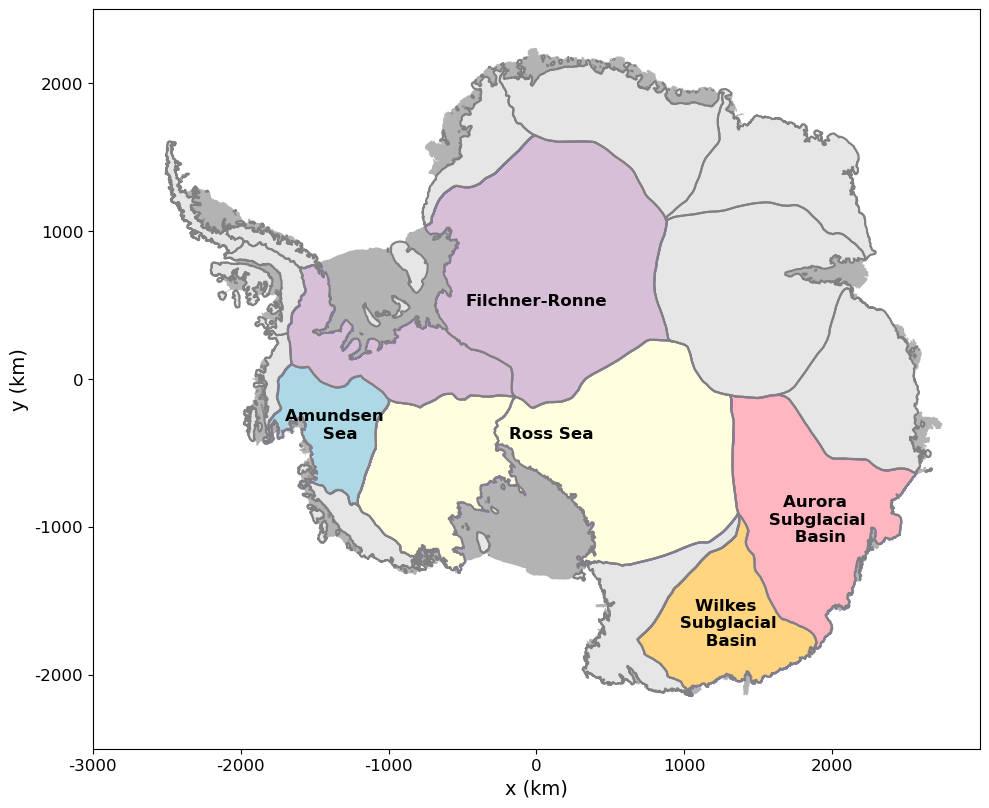

In [37]:
dir = '/Volumes/FMac/computing/data/basins/'
dir2 = '/Volumes/FMac/computing/data/antarctica/imbie/'

fig, ax = plt.subplots(figsize=(10, 10))
imbiec = dir2 + 'imbie_coastline.shp'
ct = gpd.read_file(imbiec)
ct.plot(ax=ax, color=(0.7,0.7,0.7))

gr2 = gpd.read_file(dir+'ANT_Basins_IMBIE2_v1.6.shp')
gr2.plot(ax=ax, color=(0.9,0.9,0.9))

# get Filchner-Ronne data
filchronne = ['J-Jpp', 'Jpp-K']
#filchronne = ['J-Jpp', 'Jpp-K']
for i,code in enumerate(filchronne):
    imbieb = f'{dir2}imbie_{code}.shp'
    gr = gpd.read_file(imbieb)
    line = gr.geometry.iloc[0]
    polygon = Polygon(line)
    gr.plot(ax=ax, color='pink')
    enclosed_area = polygon.area
    gpd.GeoSeries([polygon]).plot(ax=ax, color='#D8BFD8', alpha=1, edgecolor='blue', label='Enclosed Polygon')

# get Wilkes data
wilkes = ['D-Dp']
for i,code in enumerate(wilkes):
    imbieb = f'{dir2}imbie_{code}.shp'
    gr = gpd.read_file(imbieb)
    line = gr.geometry.iloc[0]
    polygon = Polygon(line)
    gr.plot(ax=ax, color='pink')
    enclosed_area = polygon.area
    gpd.GeoSeries([polygon]).plot(ax=ax, color='#FFD580', alpha=1, edgecolor='blue', label='Enclosed Polygon')

# get Aurora data
aurora = ['Cp-D']
for i,code in enumerate(aurora):
    imbieb = f'{dir2}imbie_{code}.shp'
    gr = gpd.read_file(imbieb)
    line = gr.geometry.iloc[0]
    polygon = Polygon(line)
    gr.plot(ax=ax, color='pink')
    enclosed_area = polygon.area
    gpd.GeoSeries([polygon]).plot(ax=ax, color='lightpink', alpha=1, edgecolor='blue', label='Enclosed Polygon')

# get Ross data
ross = ['Ep-F', 'E-Ep']
for i,code in enumerate(ross):
    imbieb = f'{dir2}imbie_{code}.shp'
    gr = gpd.read_file(imbieb)
    line = gr.geometry.iloc[0]
    polygon = Polygon(line)
    gr.plot(ax=ax, color='pink')
    enclosed_area = polygon.area
    gpd.GeoSeries([polygon]).plot(ax=ax, color='lightyellow', alpha=1, edgecolor='blue', label='Enclosed Polygon')

# get Amundsen data
amundsen = ['G-H']
for i,code in enumerate(amundsen):
    imbieb = f'{dir2}imbie_{code}.shp'
    gr = gpd.read_file(imbieb)
    line = gr.geometry.iloc[0]
    polygon = Polygon(line)
    gr.plot(ax=ax, color='pink')
    enclosed_area = polygon.area
    gpd.GeoSeries([polygon]).plot(ax=ax, color='lightblue', alpha=1, edgecolor='blue', label='Enclosed Polygon')

imbies = dir2 + 'imbie_basins.shp'
gr = gpd.read_file(imbies)
gr.plot(ax=ax, color='gray')

xticks = np.arange(-3e6, 3e6, 1e6)
yticks = np.arange(-3e6, 3e6, 1e6)
ax.set_xticks(xticks)
ax.set_yticks(yticks)
xlabels = [f'{int(tick/1e3)}' for tick in xticks]
ylabels = [f'{int(tick/1e3)}' for tick in yticks]
ax.set_xticklabels(xlabels, fontsize=12)
ax.set_yticklabels(ylabels, fontsize=12)

# Customize the axis labels
ax.set_xlabel("x (km)", fontsize=14)
ax.set_ylabel("y (km)", fontsize=14)
ax.set_xlim([-3e6, 3e6])
ax.set_ylim([-2.5e6, 2.5e6])

# Add text annotations on 5 polygons
btext = {filchronne[1]:(100e3, -700e3),
    filchronne[0]:(-800e3, -80e3),
    amundsen[0]:(-1350e3, 400e3),
    ross[0]:(-700e3, 600e3),
    ross[1]:(700e3, 500e3),
    aurora[0]:(1850e3, 900e3),
    wilkes[0]:(1250e3, 1700e3)}

btext2 = {'Filchner-Ronne':(0, -500e3),
    'Amundsen \n Sea':(-1350e3, 400e3),
    'Ross Sea':(100e3, 400e3),
    'Aurora \n Subglacial \n Basin':(1900e3, 1100e3),
    'Wilkes \n Subglacial \n Basin':(1300e3, 1800e3)}

# for key, value in btext.items():
#     (x,y) = value
#     ax.text(x, -y, key, fontsize=12, ha='center', color='black') #, fontweight='bold')
for key, value in btext2.items():
    (x,y) = value
    ax.text(x, -y, key, fontsize=12, ha='center', color='black', fontweight='bold')

# Show the plot
plt.tight_layout()

plt.savefig("figs/paper/fig2_imbie_basins.png")
plt.savefig("figs/paper/fig2_imbie_basins.pdf")
plt.show()

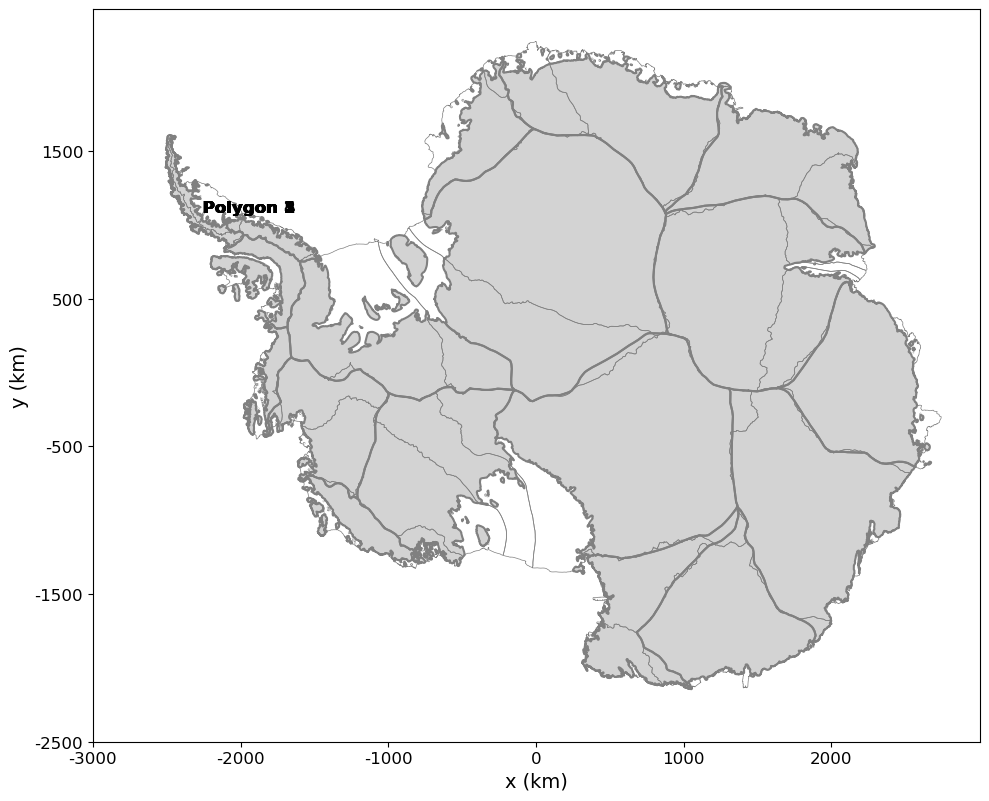

In [4]:
# dir = '/Volumes/FMac/computing/data/basins/'
# dir2 = '/Volumes/FMac/computing/data/antarctica/'

# fig, ax = plt.subplots(figsize=(10, 10))
# for i in range(27):
#     secname = dir + 'Ant_Full_DrainageSystem_Polygons_XY_' + str(i+1) + '.txt'
#     dsec = pd.read_csv(secname, delim_whitespace=True, skiprows=7, header=None, names=["x", "y"])
#     x = dsec['x']
#     y = dsec['y']
#     ax.plot(x, -y, color='gray', linewidth=0.5)

# gr2 = gpd.read_file(dir+'ANT_Basins_IMBIE2_v1.6.shp')
# gr2.plot(ax=ax, color='lightgray')

# imbies = dir2 + 'imbie/imbie_basins.shp'
# gr = gpd.read_file(imbies)
# gr.plot(ax=ax, color='gray')

# xticks = np.arange(-3e6, 3e6, 1e6)
# yticks = np.arange(-2.5e6, 2.5e6, 1e6)
# ax.set_xticks(xticks)
# ax.set_yticks(yticks)
# xlabels = [f'{int(tick/1e3)}' for tick in xticks]
# ylabels = [f'{int(tick/1e3)}' for tick in yticks]
# ax.set_xticklabels(xlabels, fontsize=12)
# ax.set_yticklabels(ylabels, fontsize=12)

# # Customize the axis labels
# ax.set_xlabel("x (km)", fontsize=14)
# ax.set_ylabel("y (km)", fontsize=14)

# # Add text annotations on 5 polygons
# text_positions = [
#     (x.iloc[0], y.iloc[0]),  # Example positions for annotation
#     (x.iloc[10], y.iloc[10]),
#     (x.iloc[15], y.iloc[15]),
#     (x.iloc[20], y.iloc[20]),
#     (x.iloc[25], y.iloc[25])
# ]

# for i, (x_pos, y_pos) in enumerate(text_positions):
#     ax.text(x_pos, -y_pos, f"Polygon {i+1}", fontsize=12, ha='center', color='black', fontweight='bold')

# # Show the plot
# plt.tight_layout()

# plt.show()

In [19]:
gr_buffer

0    POLYGON ((-6.21e+05 7.71e+05, -6.21e+05 7.71e+...
dtype: geometry